<a href="https://colab.research.google.com/github/youkjang/gefs_temperature_bias_correction/blob/main/01_mean_bias_correction_with_source_files.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GEFS 2-m Temperature Mean-Bias Correction with Source Files

This notebook demonstrates a source-file-based workflow for correcting systematic 2-m temperature bias in NOAA GEFS ensemble-mean forecasts over the CONUS domain. The main calculations are imported from the `gefs_bias_correction/` source package in this GitHub repository.

## Objective
- Evaluate whether a simple lead-time-dependent spatial mean-bias correction can improve GEFS 2-m temperature forecasts when verified against matching GFS analysis fields.

## Data
### Forecast dataset

- Model: GEFS
- Variable: 2-m temperature
- Product: ensemble mean
- Initialization dates: January 1–30, 2024
- Domain: CONUS
- Forecast lead times: f024, f048, f072, f096, f120

### Verification dataset

- Model/analysis: GFS analysis
- Variable: 2-m temperature
- Valid time: matched to each GEFS forecast valid time
- Grid: interpolated to the GEFS forecast grid


## 1. Install packages

In [1]:
!pip install git+https://github.com/youkjang/gefs_temperature_bias_correction.git

  Cloning https://github.com/youkjang/gefs_temperature_bias_correction.git to /tmp/pip-req-build-rhx2i1eb
  Running command git clone --filter=blob:none --quiet https://github.com/youkjang/gefs_temperature_bias_correction.git /tmp/pip-req-build-rhx2i1eb
  Resolved https://github.com/youkjang/gefs_temperature_bias_correction.git to commit 97a845fcecd4fd23dea9b5c5fa5872983e8d10b8
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
!pip -q install "eccodes>=2.37.0" cfgrib s3fs "fsspec==2025.3.0"

## 2. Imports

In [14]:
import numpy as np

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from gefs_bias_correction.config import ProjectConfig, Region
from gefs_bias_correction.synthetic import make_synthetic_t2m_dataset
from gefs_bias_correction.data_access import build_matched_t2m_dataset
from gefs_bias_correction.split import split_train_test_by_init_date
from gefs_bias_correction.mean_bias import compute_mean_bias_by_lead, apply_mean_bias_correction
from gefs_bias_correction.verification import make_summary_table
from gefs_bias_correction.plotting import plot_rmse_summary, plot_spatial_map

## 3. Configuration

In [16]:
USE_SYNTHETIC = False  # True for quick debugging; False for real GEFS/GFS data

config = ProjectConfig(
    init_dates=pd.date_range("2024-01-01", "2024-01-30", freq="D").strftime("%Y%m%d").tolist(),
    init_hour="00",
    forecast_hours=[24, 48, 72, 96, 120],
    train_fraction=0.7,
    region=Region(name="CONUS", west=-130, east=-60, south=20, north=55),
    cache_dir="data/herbie_cache",
    verbose=True,
    skip_missing=True,
)

config

ProjectConfig(init_dates=['20240101', '20240102', '20240103', '20240104', '20240105', '20240106', '20240107', '20240108', '20240109', '20240110', '20240111', '20240112', '20240113', '20240114', '20240115', '20240116', '20240117', '20240118', '20240119', '20240120', '20240121', '20240122', '20240123', '20240124', '20240125', '20240126', '20240127', '20240128', '20240129', '20240130'], init_hour='00', forecast_hours=[24, 48, 72, 96, 120], train_fraction=0.7, region=Region(name='CONUS', west=-130, east=-60, south=20, north=55), cache_dir=PosixPath('data/herbie_cache'), verbose=True, skip_missing=True)

## 4. Load dataset

In [17]:
if USE_SYNTHETIC:
    ds = make_synthetic_t2m_dataset(config)
else:
    ds = build_matched_t2m_dataset(config)

ds

Loading init=20240101 00Z, f024, valid=2024-01-02 00Z
 ╭─▌▌Herbie─────────────────────────────────────────────╮
 │ INFO: Created a default config file.                 │
 │ You may view/edit Herbie's configuration here:       │
 │          /root/.config/herbie/config.toml            │
 ╰──────────────────────────────────────────────────────╯

✅ Found ┊ model=gefs ┊ product=atmos.5 ┊ 2024-Jan-01 00:00 UTC F24 ┊ GRIB2 @ aws ┊ IDX @ aws
✅ Found ┊ model=gfs ┊ product=pgrb2.0p25 ┊ 2024-Jan-02 00:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ aws


/usr/local/lib/python3.12/dist-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)


Note: Returning a list of [2] xarray.Datasets because cfgrib opened with multiple hypercubes.
Loading init=20240101 00Z, f048, valid=2024-01-03 00Z
✅ Found ┊ model=gefs ┊ product=atmos.5 ┊ 2024-Jan-01 00:00 UTC F48 ┊ GRIB2 @ aws ┊ IDX @ aws
✅ Found ┊ model=gfs ┊ product=pgrb2.0p25 ┊ 2024-Jan-03 00:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ aws


/usr/local/lib/python3.12/dist-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)


Note: Returning a list of [2] xarray.Datasets because cfgrib opened with multiple hypercubes.
Loading init=20240101 00Z, f072, valid=2024-01-04 00Z
✅ Found ┊ model=gefs ┊ product=atmos.5 ┊ 2024-Jan-01 00:00 UTC F72 ┊ GRIB2 @ aws ┊ IDX @ aws
✅ Found ┊ model=gfs ┊ product=pgrb2.0p25 ┊ 2024-Jan-04 00:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ aws


...

/usr/local/lib/python3.12/dist-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)


Note: Returning a list of [2] xarray.Datasets because cfgrib opened with multiple hypercubes.
Loading init=20240130 00Z, f120, valid=2024-02-04 00Z
✅ Found ┊ model=gefs ┊ product=atmos.5 ┊ 2024-Jan-30 00:00 UTC F120 ┊ GRIB2 @ aws ┊ IDX @ aws
✅ Found ┊ model=gfs ┊ product=pgrb2.0p25 ┊ 2024-Feb-04 00:00 UTC F00 ┊ GRIB2 @ aws ┊ IDX @ aws


/usr/local/lib/python3.12/dist-packages/cfgrib/xarray_store.py:51: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  o = xr.merge([o, ds], **kwargs)


Note: Returning a list of [2] xarray.Datasets because cfgrib opened with multiple hypercubes.


<xarray.Dataset> Size: 18MB
Dimensions:              (case: 150, latitude: 71, longitude: 141)
Coordinates:
  * case                 (case) int64 1kB 0 1 2 3 4 5 ... 145 146 147 148 149
  * latitude             (latitude) float64 568B 20.0 20.5 21.0 ... 54.5 55.0
  * longitude            (longitude) float64 1kB -130.0 -129.5 ... -60.5 -60.0
    gribfile_projection  object 8B None
    init_date            (case) datetime64[us] 1kB 2024-01-01 ... 2024-01-30
    fhr                  (case) int64 1kB 24 48 72 96 120 24 ... 24 48 72 96 120
    valid_time           (case) datetime64[us] 1kB 2024-01-02 ... 2024-02-04
Data variables:
    forecast_t2m_c       (case, latitude, longitude) float32 6MB 20.26 ... -2...
    analysis_t2m_c       (case, latitude, longitude) float64 12MB 20.79 ... -...

In [18]:
print("Dataset variables:", list(ds.data_vars))
print("Number of cases:", ds.sizes["case"])
print("Forecast hours:", np.unique(ds["fhr"].values))
print("Init dates:", np.unique(ds["init_date"].values))
print("First valid times:", ds["valid_time"].values[:5])

print("Forecast min/max:",
      float(ds["forecast_t2m_c"].min()),
      float(ds["forecast_t2m_c"].max()))

print("Analysis min/max:",
      float(ds["analysis_t2m_c"].min()),
      float(ds["analysis_t2m_c"].max()))

Dataset variables: ['forecast_t2m_c', 'analysis_t2m_c']
Number of cases: 150
Forecast hours: [ 24  48  72  96 120]
Init dates: ['2024-01-01T00:00:00.000000' '2024-01-02T00:00:00.000000'
 '2024-01-03T00:00:00.000000' '2024-01-04T00:00:00.000000'
 '2024-01-05T00:00:00.000000' '2024-01-06T00:00:00.000000'
 '2024-01-07T00:00:00.000000' '2024-01-08T00:00:00.000000'
 '2024-01-09T00:00:00.000000' '2024-01-10T00:00:00.000000'
 '2024-01-11T00:00:00.000000' '2024-01-12T00:00:00.000000'
 '2024-01-13T00:00:00.000000' '2024-01-14T00:00:00.000000'
 '2024-01-15T00:00:00.000000' '2024-01-16T00:00:00.000000'
 '2024-01-17T00:00:00.000000' '2024-01-18T00:00:00.000000'
 '2024-01-19T00:00:00.000000' '2024-01-20T00:00:00.000000'
 '2024-01-21T00:00:00.000000' '2024-01-22T00:00:00.000000'
 '2024-01-23T00:00:00.000000' '2024-01-24T00:00:00.000000'
 '2024-01-25T00:00:00.000000' '2024-01-26T00:00:00.000000'
 '2024-01-27T00:00:00.000000' '2024-01-28T00:00:00.000000'
 '2024-01-29T00:00:00.000000' '2024-01-30T00:00

## 5. Basic sanity checks

In [19]:
print("Forecast range (°C):", float(ds["forecast_t2m_c"].min()), float(ds["forecast_t2m_c"].max()))
print("Analysis range (°C):", float(ds["analysis_t2m_c"].min()), float(ds["analysis_t2m_c"].max()))
print("Forecast hours:", sorted(set(ds["fhr"].values.tolist())))
print("Number of cases:", ds.sizes["case"])

Forecast range (°C): -38.989990234375 31.399993896484375
Analysis range (°C): -40.025360107421875 31.6143798828125
Forecast hours: [24, 48, 72, 96, 120]
Number of cases: 150


## 6. Split train/test by initialization date

In [20]:
train_ds, test_ds, train_dates, test_dates = split_train_test_by_init_date(ds, train_fraction=config.train_fraction)

print("Training dates:", train_dates[:5], "...", train_dates[-5:])
print("Testing dates:", test_dates[:5], "...", test_dates[-5:])
print("Training cases:", train_ds.sizes["case"])
print("Testing cases:", test_ds.sizes["case"])

Training dates: ['20240101', '20240102', '20240103', '20240104', '20240105'] ... ['20240117', '20240118', '20240119', '20240120', '20240121']
Testing dates: ['20240122', '20240123', '20240124', '20240125', '20240126'] ... ['20240126', '20240127', '20240128', '20240129', '20240130']
Training cases: 105
Testing cases: 45


## 7. Compute lead-time-dependent mean bias

In [21]:
mean_bias_by_lead = compute_mean_bias_by_lead(train_ds)
mean_bias_by_lead

<xarray.DataArray 'mean_bias_c' (fhr: 5, latitude: 71, longitude: 141)> Size: 400kB
array([[[-0.43469674, -0.46041434, -0.48993065, ..., -0.28231521,
         -0.24612281, -0.28612264],
        [-0.40183658, -0.44659569, -0.44564238, ..., -0.28088234,
         -0.20945812, -0.27993629],
        [-0.3885033 , -0.39707293, -0.44040498, ..., -0.25564139,
         -0.23183768, -0.22136143],
        ...,
        [-1.01279268, -1.48326619, -0.65040661, ...,  0.97816685,
          0.42006938,  0.79721215],
        [-0.8804096 , -0.5094619 , -0.53708104, ...,  0.14720808,
         -0.11373756,  0.43625968],
        [-0.65374465, -0.90850612, -0.18326314, ...,  0.02768744,
          0.35959516, -0.02612377]],

       [[-0.53396025, -0.53491211, -0.54015096, ..., -0.36110142,
         -0.30157907, -0.33872187],
        [-0.5239563 , -0.52824184, -0.50157529, ..., -0.35348365,
         -0.31157721, -0.35110474],
        [-0.50062488, -0.47205607, -0.4815732 , ..., -0.30110096,
         -0.2939613 , -0.28538586],
...
        [-0.94887434, -1.27792358, -0.31077503, ...,  0.45398676,
         -0.02029855,  0.26112947],
        [-0.65267799, -0.1526838 , -0.16696894, ..., -0.37792097,
         -0.75648935, -0.33459037],
        [-0.29220654, -0.32696606,  0.38065447, ..., -0.53220476,
         -0.45934841, -1.00458781]],

       [[-0.41710263, -0.42614891, -0.42138817, ..., -0.42044067,
         -0.38424247, -0.41281709],
        [-0.4366208 , -0.42186337, -0.40138463, ..., -0.45948428,
         -0.44091216, -0.48233759],
        [-0.44471959, -0.39900571, -0.40233648, ..., -0.47805205,
         -0.47806077, -0.50567191],
        ...,
        [-0.50519816, -0.91377258,  0.18813651, ..., -0.29662214,
         -0.80757868, -0.66185942],
        [-0.074242  ,  0.4452769 ,  0.3948001 , ..., -1.19710068,
         -1.53900219, -1.19138663],
        [ 0.23289998,  0.30861337,  1.05337379, ..., -1.4699569 ,
         -1.35948181, -1.86567397]]])
Coordinates:
  * fhr                  (fhr) int64 40B 24 48 72 96 120
  * latitude             (latitude) float64 568B 20.0 20.5 21.0 ... 54.5 55.0
  * longitude            (longitude) float64 1kB -130.0 -129.5 ... -60.5 -60.0
    gribfile_projection  object 8B None
Attributes: (12/28)
    GRIB_paramId:                             167
    GRIB_typeOfLevel:                         heightAboveGround
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    GRIB_gridType:                            regular_ll
    GRIB_uvRelativeToGrid:                    0
    ...                                       ...
    GRIB_totalNumber:                         30
    GRIB_units:                               K
    long_name:                                Training mean bias by forecast ...
    units:                                    degC
    standard_name:                            air_temperature
    grid_mapping:                             gribfile_projection

## 8. Apply mean-bias correction

In [22]:
corrected = apply_mean_bias_correction(test_ds, mean_bias_by_lead)
corrected

<xarray.DataArray 'corrected_t2m_c' (case: 45, latitude: 71, longitude: 141)> Size: 4MB
array([[[ 2.12547041e+01,  2.12104143e+01,  2.10999465e+01, ...,
          2.55723238e+01,  2.54361253e+01,  2.54461263e+01],
        [ 2.11618463e+01,  2.11265884e+01,  2.10156497e+01, ...,
          2.54908738e+01,  2.53394630e+01,  2.53599534e+01],
        [ 2.10185082e+01,  2.09370815e+01,  2.09003964e+01, ...,
          2.54956621e+01,  2.54118304e+01,  2.53513663e+01],
        ...,
        [ 2.78281221e+00,  1.12328084e+00, -4.59578741e-01, ...,
         -1.28481620e+01, -1.36000621e+01, -1.35472121e+01],
        [ 1.86042059e+00, -1.12054298e+00, -2.23290798e+00, ...,
         -1.19972142e+01, -1.16762710e+01, -1.27062487e+01],
        [-2.62480236e-02, -1.65149144e+00, -3.80672709e+00, ...,
         -1.26276935e+01, -1.19596013e+01, -1.10538628e+01]],

       [[ 2.17939700e+01,  2.16949158e+01,  2.15501607e+01, ...,
          2.52711051e+01,  2.50915876e+01,  2.50887219e+01],
        [ 2.15939636e+01,  2.15282418e+01,  2.13815802e+01, ...,
          2.50334763e+01,  2.48915943e+01,  2.48811035e+01],
        [ 2.13706200e+01,  2.12820536e+01,  2.11915647e+01, ...,
          2.46410973e+01,  2.45639808e+01,  2.44653785e+01],
...
        [-1.16111101e+00, -2.21206665e+00, -2.29921032e+00, ...,
         -2.50239788e+01, -2.51796984e+01, -2.47711240e+01],
        [-2.35730126e+00, -4.76729911e+00, -3.62303961e+00, ...,
         -2.57720729e+01, -2.51235003e+01, -2.53553968e+01],
        [-2.46777271e+00, -4.10302662e+00, -4.51065935e+00, ...,
         -2.59177922e+01, -2.51606467e+01, -2.41853994e+01]],

       [[ 2.11671026e+01,  2.10561538e+01,  2.09613967e+01, ...,
          2.49004517e+01,  2.47542376e+01,  2.47528134e+01],
        [ 2.08666135e+01,  2.07218817e+01,  2.05913871e+01, ...,
          2.48094904e+01,  2.47709292e+01,  2.47923351e+01],
        [ 2.06747306e+01,  2.04890020e+01,  2.02823414e+01, ...,
          2.47080630e+01,  2.46580534e+01,  2.46056780e+01],
        ...,
        [-1.63478597e+00, -4.40623474e+00, -5.77813285e+00, ...,
         -2.19233791e+01, -2.25124134e+01, -2.16281339e+01],
        [-3.15573847e+00, -7.78527323e+00, -7.29479399e+00, ...,
         -2.21428957e+01, -2.21209862e+01, -2.26186109e+01],
        [-3.59288534e+00, -6.87862069e+00, -8.22335670e+00, ...,
         -2.20300431e+01, -2.19605103e+01, -2.12243224e+01]]])
Coordinates:
  * case                 (case) int64 360B 105 106 107 108 ... 146 147 148 149
  * latitude             (latitude) float64 568B 20.0 20.5 21.0 ... 54.5 55.0
  * longitude            (longitude) float64 1kB -130.0 -129.5 ... -60.5 -60.0
    gribfile_projection  object 8B None
    init_date            (case) datetime64[us] 360B 2024-01-22 ... 2024-01-30
    fhr                  (case) int64 360B 24 48 72 96 120 ... 24 48 72 96 120
    valid_time           (case) datetime64[us] 360B 2024-01-23 ... 2024-02-04
Attributes: (12/36)
    GRIB_paramId:                             167
    GRIB_dataType:                            pf
    GRIB_numberOfPoints:                      259920
    GRIB_typeOfLevel:                         heightAboveGround
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         30
    GRIB_units:                               K
    units:                                    degC
    standard_name:                            air_temperature
    grid_mapping:                             gribfile_projection
    long_name:                                Bias-corrected GEFS ensemble-me...

## 9. Verify raw vs corrected forecasts

In [23]:
summary = make_summary_table(test_ds, corrected)
summary

,fhr,n_cases_raw,bias_c_raw,bias_c_corrected,abs_bias_improvement_c,rmse_c_raw,rmse_c_corrected,rmse_improvement_c,mae_c_raw,mae_c_corrected,mae_improvement_c
0,24,9,0.160674,0.156472,0.004202,1.103769,1.048093,0.055676,0.744936,0.712699,0.032237
1,48,9,0.092458,0.122388,-0.029930,1.367180,1.313669,0.053510,0.905928,0.871228,0.034699
2,72,9,-0.063342,0.020842,0.042500,1.748573,1.715105,0.033468,1.089329,1.069307,0.020022
3,96,9,-0.241477,-0.106007,0.135470,2.162458,2.128495,0.033963,1.283406,1.251897,0.031509
4,120,9,-0.447915,-0.314562,0.133353,2.591680,2.582553,0.009127,1.503377,1.507997,-0.004620


- The correction silghtly reduces RMSE at all forecast lead time.
- The bias improvement is not positive at every lead time.
- The MAE improvves for f024-f096, but slightly worsens at f190.

## 10. Plot RMSE summary

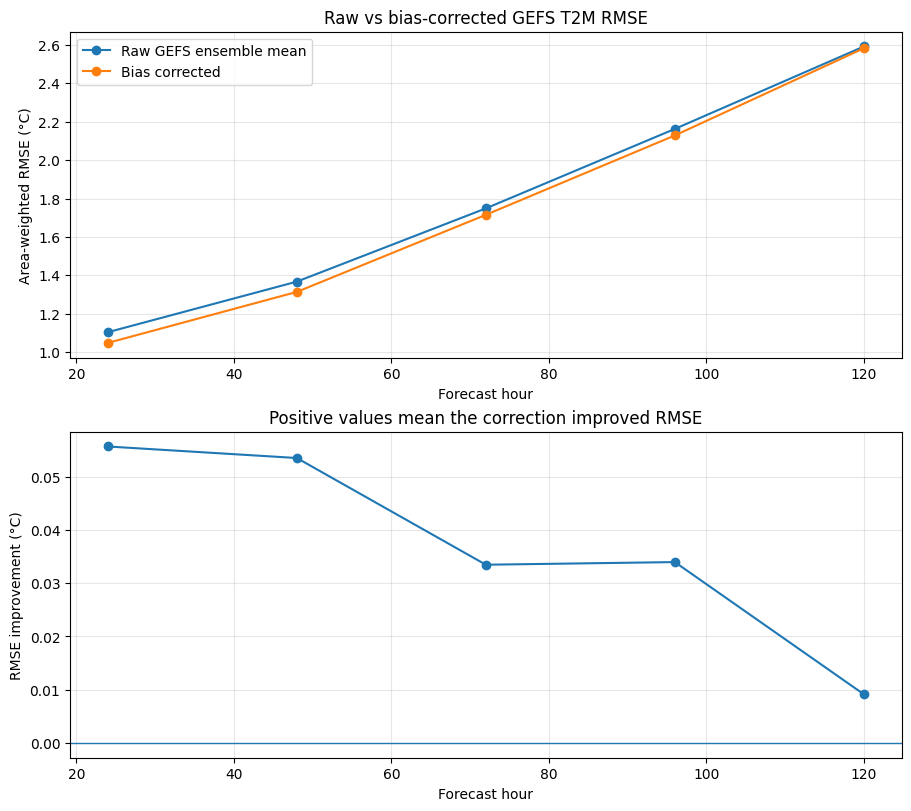

In [24]:
fig, axes = plot_rmse_summary(summary, save_path="outputs/figures/rmse_raw_vs_corrected.png")
plt.show()

- The lead-time-dependent mean-bias correction modestly but consistently improves RMSE for this January 2024 real-data test.

## 11. Plot example bias maps

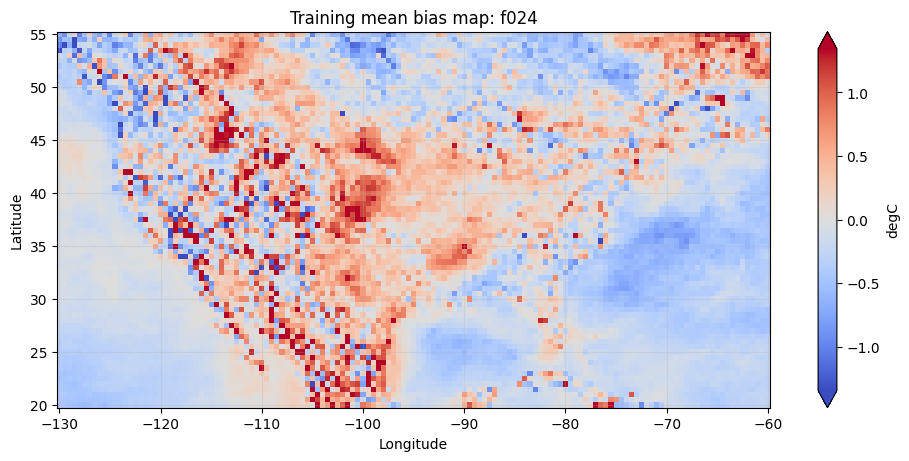

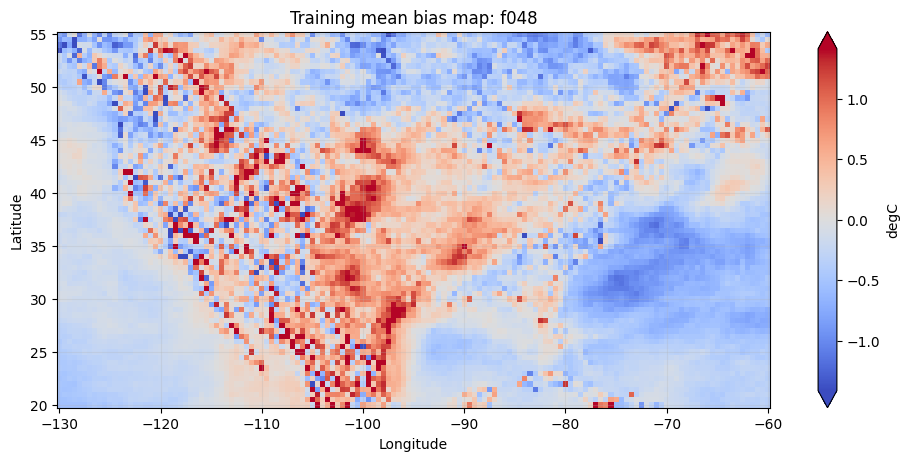

In [27]:
for fhr in mean_bias_by_lead["fhr"].values[:2]:
    da = mean_bias_by_lead.sel(fhr=int(fhr))
    fig, ax = plot_spatial_map(
        da,
        title=f"Training mean bias map: f{int(fhr):03d}",
        save_path=f"outputs/figures/mean_bias_f{int(fhr):03d}.png",
    )
    plt.show()

- The training mean-bias maps show spatially varing GEFS 2-m temperature erros during the training period.
- Bias is defined as forecast minus analysis -> red: warm bias, blue: cold bias


## 12. Summary and discussion

### Main findings

The real-data experiment shows that raw GEFS ensemble-mean 2-m temperature RMSE increases with forecast lead time. After applying the lead-time-dependent spatial mean-bias correction, RMSE is modestly reduced at all tested forecast hours from f024 to f120.

### Next steps

1. Increase the training and testing period to include more initialization dates.
3. Compare mean-bias correction with quantile mapping.
4. Develop machine-learning bias correction using predictors such as forecast hour, latitude, longitude, day of year, and raw GEFS temperature.

### Conclusion

This source-file version successfully reproduces the GEFS 2-m temperature bias-correction workflow in a modular and reusable form. The initial real-data results show that a simple lead-time-dependent spatial mean-bias correction can modestly improve GEFS ensemble-mean temperature RMSE on independent test cases.


###Note on AI Assistance

This notebook was developed with AI-assisted coding support. See the repository README for details.